In [1]:
# Step 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import pickle

In [2]:
# Step 2: Load Data
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Step 3: Select Features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [4]:
# Step 4: transform using scaler
import joblib

scaler = joblib.load("../models/scaler.pkl")
X_scaled = scaler.transform(X)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [5]:
# Step 5: Apply PCA (AUTO 95% VARIANCE)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Shape before PCA:", X_scaled.shape)
print("Shape after PCA:", X_pca.shape)

Shape before PCA: (200, 2)
Shape after PCA: (200, 2)


In [6]:
# Step 6: Explained Variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.50495142 0.49504858]
Total Variance Retained: 1.0


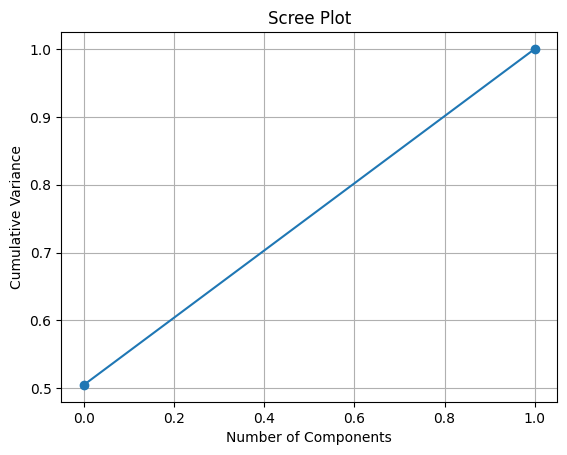

In [7]:
# Step 7: Scree Plot (IMPORTANT 🔥)
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

In [8]:
# Step 8: Save PCA Model
pickle.dump(pca, open("../models/pca.pkl", "wb"))

# Save scaler also in models (IMPORTANT FIX)
pickle.dump(scaler, open("../models/scaler.pkl", "wb"))